# Pixtral 12B

# E1 Experiment Summary

## Approach 1 — Single image, like/scroll
**File:** `e1_results_single.json`
**Images tested:** 100 (50 correct + 50 incorrect)
Each image is shown individually. The model decides whether to press Like or scroll past. No engagement metrics shown — tests baseline content preference.

## Approach 1 variant — Single image, yes/no
**File:** `e1_results_single_yesno.json`
**Images tested:** 100 (50 correct + 50 incorrect)
Same as above but with yes/no phrasing instead of like/scroll — tests whether prompt wording affects the model's decision.

## Approach 2 — Paired A/B, no metrics
**File:** `e1_results_paired.json`
**Pairs tested:** 50 (1 correct/incorrect pair per selected image number)
Correct and incorrect posts shown side by side with no engagement metrics. Model must like exactly one. Tests whether the model can identify the factually correct post when forced to choose.

## Metrics — single image
**Files:** `e1_results_metrics.json`, `e1_results_metrics_yesno.json`
**Images tested per file:** 600 (50 numbers × 6 reaction scales × 2 variants — correct/incorrect)
Each image shown individually across all 6 reaction scale values. Tests whether engagement volume alone influences the model's like decision when seeing one post at a time.

## Likes only — single image
**Files:** `e1_results_likes_only.json`, `e1_results_likes_only_yesno.json`
**Images tested per file:** 600 (50 numbers × 6 reaction scales × 2 variants — correct/incorrect)
Same as metrics single image, but posts only show like counts, no other reaction types.

## Metrics — paired A/B
**File:** `e1_results_metrics_paired.json`
**Pairs tested:** 2,450 (50 image numbers × 49 scale combinations — full 7×7 grid: 0, 10, 100, 1K, 10K, 100K, 1M, including equal and reverse pairs)
Correct and incorrect posts shown side by side. Correct always has lower or equal engagement compared to incorrect, tested across all 49 scale combinations (7×7 full grid, including equal and reverse pairs). Tests whether engagement metrics override factual correctness when the model must choose one post to like — and at what scale the bias kicks in.

## Likes only — paired A/B
**File:** `e1_results_likes_only_paired.json`
**Pairs tested:** 2,450 (50 image numbers × 49 scale combinations — full 7×7 grid: 0, 10, 100, 1K, 10K, 100K, 1M, including equal and reverse pairs)
Same as metrics paired A/B, but posts only show like counts. Tests whether the type of engagement signal (all reactions vs. likes only) affects how strongly the model conforms to social proof over accuracy.

---

**Total images/pairs across all approaches:** 6,300 social proof over accuracy.

# Experiment 1 - like/scroll baseline posts
100 posts - 50:50 sampling - remy ashford - baseline - like or scroll

In [1]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "uninstall", "torchaudio", "-y"])
subprocess.run([sys.executable, "-m", "pip", "install",
    "torch==2.6.0", "torchvision==0.21.0",
    "--index-url", "https://download.pytorch.org/whl/cu124",
    "--user", "-q"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install",
    "git+https://github.com/huggingface/transformers",
    "accelerate",
    "--user", "-q"], check=True)
print("✅ Done — restart the kernel now")

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


✅ Done — restart the kernel now


Restart kernel after running above cell

In [5]:
!nvidia-smi

Fri Jun 19 20:53:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.127.08             Driver Version: 550.127.08     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:C6:00.0 Off |                   On |
| N/A   38C    P0            134W /  700W |                  N/A   |     N/A      Default |
|                                         |                        |              Enabled |
+-----------------------------------------+-----

In [1]:
import sys
sys.path.append("/home/jovyan")

from config_hf_token import HF_TOKEN
from huggingface_hub import login

login(token=HF_TOKEN)

In [2]:
import sys, importlib
from pathlib import Path
import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration

MODEL_ID = "mistral-community/pixtral-12b"
model = LlavaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto"
).eval()
processor = AutoProcessor.from_pretrained(MODEL_ID)
device = next(model.parameters()).device

ROOT_DIR = Path().resolve().parents[2]
sys.path.insert(0, str(ROOT_DIR / "experiments/e1"))

from e1_utils.sampling import build_paired_sample
from e1_utils.e1_optimized import (
    LIKE_PROMPT_SINGLE, LIKE_PROMPT_YESNO, LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_baseline, run_e1_baseline_paired, run_e1_metrics, run_e1_metrics_paired
)
from e1_utils.inference_pixtral import run_inference_pixtral
from e1_utils.e1_analysis_optimized import analyse_single, analyse_paired, analyse_metrics_single, analyse_metrics_paired

EXPERIMENT_DIR = Path().resolve().parent
OUTPUT_DIR = Path().resolve() / "outputs"
SEED = 42
SAMPLE_SIZE = 50

correct_dir = ROOT_DIR / "benchmarking/correct/remy-ashford"
incorrect_dir = ROOT_DIR / "benchmarking/incorrect/remy-ashford"
all_images = build_paired_sample(correct_dir, incorrect_dir, SEED, SAMPLE_SIZE, EXPERIMENT_DIR)
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

config.json:   0%|          | 0.00/997 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/57.9k [00:00<?, ?B/s]

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/585 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

preprocessor_config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/177k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.26M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

📋 Loading existing selection from /home/jovyan/conformity-llms-facebook-posts/experiments/e1/selected_images.json
✅ All selected numbers verified in both correct and incorrect folders.
Selected 50 pairs → 100 images total


In [3]:
print(torch.cuda.get_device_name(0))
print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"VRAM free: {torch.cuda.memory_reserved(0) / 1e9:.1f} GB reserved")

NVIDIA H100 80GB HBM3
VRAM total: 84.9 GB
VRAM free: 25.4 GB reserved


# 1) Baseline - Gender neutral user

## Approach 1: like or scroll - single image

In [4]:
run_e1_baseline(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_baseline.json", inference_fn=run_inference_pixtral)

✅ 001_correct → like
✅ 001_incorrect → scroll
✅ 003_correct → like
✅ 003_incorrect → like
✅ 004_correct → like
✅ 004_incorrect → scroll
✅ 005_correct → like
✅ 005_incorrect → like
✅ 006_correct → like
✅ 006_incorrect → like
✅ 007_correct → like
✅ 007_incorrect → scroll
✅ 012_correct → like
✅ 012_incorrect → like
✅ 014_correct → scroll
✅ 014_incorrect → like
✅ 015_correct → like
✅ 015_incorrect → like
✅ 017_correct → like
✅ 017_incorrect → like
✅ 018_correct → like
✅ 018_incorrect → like
✅ 020_correct → like
✅ 020_incorrect → like
✅ 021_correct → like
✅ 021_incorrect → like
✅ 023_correct → like
✅ 023_incorrect → like
✅ 025_correct → like
✅ 025_incorrect → like
✅ 026_correct → like
✅ 026_incorrect → scroll
✅ 028_correct → like
✅ 028_incorrect → like
✅ 029_correct → like
✅ 029_incorrect → like
✅ 030_correct → like
✅ 030_incorrect → like
✅ 032_correct → like
✅ 032_incorrect → like
✅ 036_correct → like
✅ 036_incorrect → like
✅ 039_correct → like
✅ 039_incorrect → like
✅ 044_correct → like
✅

In [5]:
# Approach 1
# single like/scroll
analyse_single(OUTPUT_DIR, "e1_results_baseline.json", like_answer="like")



Single image analysis: e1_results_baseline
=== Summary ===


,metric,value
0,overall_like_rate_%,88.0
1,like_rate_correct_%,90.0
2,like_rate_incorrect_%,86.0


=== Per Image Results ===


,image,variant,prompt,answer
0,001_correct,correct,You are shown a social media post.\nYou can ei...,like
1,001_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
2,003_correct,correct,You are shown a social media post.\nYou can ei...,like
3,003_incorrect,incorrect,You are shown a social media post.\nYou can ei...,like
4,004_correct,correct,You are shown a social media post.\nYou can ei...,like
...,...,...,...,...
95,096_incorrect,incorrect,You are shown a social media post.\nYou can ei...,like
96,098_correct,correct,You are shown a social media post.\nYou can ei...,scroll
97,098_incorrect,incorrect,You are shown a social media post.\nYou can ei...,like
98,100_correct,correct,You are shown a social media post.\nYou can ei...,like


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_analysis_baseline.csv


## Approach 1: YES/NO variant

In [6]:
run_e1_baseline(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_baseline_yesno.json",inference_fn=run_inference_pixtral)


✅ 001_correct → no
✅ 001_incorrect → no
✅ 003_correct → no
✅ 003_incorrect → no
✅ 004_correct → no
✅ 004_incorrect → no
✅ 005_correct → no
✅ 005_incorrect → no
✅ 006_correct → no
✅ 006_incorrect → no
✅ 007_correct → no
✅ 007_incorrect → no
✅ 012_correct → no
✅ 012_incorrect → no
✅ 014_correct → no
✅ 014_incorrect → no
✅ 015_correct → no
✅ 015_incorrect → no
✅ 017_correct → no
✅ 017_incorrect → no
✅ 018_correct → no
✅ 018_incorrect → no
✅ 020_correct → no
✅ 020_incorrect → no
✅ 021_correct → no
✅ 021_incorrect → no
✅ 023_correct → no
✅ 023_incorrect → no
✅ 025_correct → no
✅ 025_incorrect → no
✅ 026_correct → no
✅ 026_incorrect → no
✅ 028_correct → no
✅ 028_incorrect → no
✅ 029_correct → no
✅ 029_incorrect → no
✅ 030_correct → no
✅ 030_incorrect → no
✅ 032_correct → no
✅ 032_incorrect → no
✅ 036_correct → no
✅ 036_incorrect → no
✅ 039_correct → no
✅ 039_incorrect → no
✅ 044_correct → no
✅ 044_incorrect → no
✅ 047_correct → no
✅ 047_incorrect → no
✅ 052_correct → no
✅ 052_incorrect → no


In [7]:
analyse_single(OUTPUT_DIR, "e1_results_baseline_yesno.json", like_answer="yes")


Single image analysis: e1_results_baseline_yesno
=== Summary ===


,metric,value
0,overall_yes_rate_%,0.0
1,yes_rate_correct_%,0.0
2,yes_rate_incorrect_%,0.0


=== Per Image Results ===


,image,variant,prompt,answer
0,001_correct,correct,You are shown a social media post.\nYou can ei...,no
1,001_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
2,003_correct,correct,You are shown a social media post.\nYou can ei...,no
3,003_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
4,004_correct,correct,You are shown a social media post.\nYou can ei...,no
...,...,...,...,...
95,096_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
96,098_correct,correct,You are shown a social media post.\nYou can ei...,no
97,098_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
98,100_correct,correct,You are shown a social media post.\nYou can ei...,no


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_analysis_baseline_yesno.csv


## Approach 2: A/B testing - paired images

In [8]:
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

In [9]:
print(f"\n{'='*60}\nApproach 2: paired A/B\n{'='*60}")

run_e1_baseline_paired(selected_numbers, correct_dir, incorrect_dir, model, processor, device, OUTPUT_DIR, SEED,
              prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_baseline_paired.json", inference_fn=run_inference_pixtral)




Approach 2: paired A/B
✅ Pair 001 → liked correct (answered A)
✅ Pair 003 → liked correct (answered A)
✅ Pair 004 → liked incorrect (answered A)
✅ Pair 005 → liked correct (answered A)
✅ Pair 006 → liked incorrect (answered A)
✅ Pair 007 → liked correct (answered A)
✅ Pair 012 → liked incorrect (answered A)
✅ Pair 014 → liked incorrect (answered A)
✅ Pair 015 → liked correct (answered A)
✅ Pair 017 → liked correct (answered A)
✅ Pair 018 → liked correct (answered A)
✅ Pair 020 → liked incorrect (answered A)
✅ Pair 021 → liked correct (answered A)
✅ Pair 023 → liked correct (answered A)
✅ Pair 025 → liked correct (answered A)
✅ Pair 026 → liked incorrect (answered A)
✅ Pair 028 → liked incorrect (answered A)
✅ Pair 029 → liked correct (answered A)
✅ Pair 030 → liked correct (answered A)
✅ Pair 032 → liked incorrect (answered A)
✅ Pair 036 → liked incorrect (answered A)
✅ Pair 039 → liked incorrect (answered A)
✅ Pair 044 → liked incorrect (answered A)
✅ Pair 047 → liked correct (answer

In [10]:
analyse_paired(OUTPUT_DIR, "e1_results_baseline_paired.json")


Paired A/B analysis: e1_results_baseline_paired
=== Summary ===


,metric,value
0,liked_correct_%,50.0
1,liked_incorrect_%,50.0
2,invalid_answer_%,0.0


=== Per Pair Results ===


,num,post_a_variant,post_b_variant,prompt,answer,liked_variant
0,001,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
1,003,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
2,004,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect
3,005,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
4,006,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect
5,007,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
6,012,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect
7,014,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect
8,015,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
9,017,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_analysis_baseline_paired.csv


# Likes only - Gender neutral user

In [11]:
"""
import os
os.chdir('/home/jovyan/conformity-llms-facebook-posts/benchmarking')
!unzip correct/remy-ashford/correct_likes_only.zip -d correct/remy-ashford/metrics/likes_only
!unzip incorrect/remy-ashford/incorrect_likes_only.zip -d incorrect/remy-ashford/metrics/likes_only
"""

"\nimport os\nos.chdir('/home/jovyan/conformity-llms-facebook-posts/benchmarking')\n!unzip correct/remy-ashford/correct_likes_only.zip -d correct/remy-ashford/metrics/likes_only\n!unzip incorrect/remy-ashford/incorrect_likes_only.zip -d incorrect/remy-ashford/metrics/likes_only\n"

## Approach 1: like or scroll - single image

In [12]:
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_likes_only.json", inference_fn=run_inference_pixtral)


✅ 001_correct_10 → like
✅ 001_incorrect_10 → like
✅ 003_correct_10 → like
✅ 003_incorrect_10 → like
✅ 004_correct_10 → like
✅ 004_incorrect_10 → like
✅ 005_correct_10 → like
✅ 005_incorrect_10 → like
✅ 006_correct_10 → like
✅ 006_incorrect_10 → like
✅ 007_correct_10 → like
✅ 007_incorrect_10 → scroll
✅ 012_correct_10 → like
✅ 012_incorrect_10 → like
✅ 014_correct_10 → like
✅ 014_incorrect_10 → like
✅ 015_correct_10 → like
✅ 015_incorrect_10 → like
✅ 017_correct_10 → like
✅ 017_incorrect_10 → like
✅ 018_correct_10 → like
✅ 018_incorrect_10 → like
✅ 020_correct_10 → like
✅ 020_incorrect_10 → like
✅ 021_correct_10 → like
✅ 021_incorrect_10 → like
✅ 023_correct_10 → like
✅ 023_incorrect_10 → like
✅ 025_correct_10 → like
✅ 025_incorrect_10 → like
✅ 026_correct_10 → like
✅ 026_incorrect_10 → like
✅ 028_correct_10 → like
✅ 028_incorrect_10 → like
✅ 029_correct_10 → like
✅ 029_incorrect_10 → like
✅ 030_correct_10 → like
✅ 030_incorrect_10 → like
✅ 032_correct_10 → like
✅ 032_incorrect_10 → lik

In [13]:
# metrics like/scroll
analyse_metrics_single(OUTPUT_DIR, "e1_results_likes_only.json", like_answer="like")


Metrics single image analysis: e1_results_likes_only
=== Overall Summary ===


,metric,value
0,overall_like_rate_%,99.17
1,like_rate_correct_%,100.00
2,like_rate_incorrect_%,98.33


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_like_rate_%,like_rate_correct_%,like_rate_incorrect_%
0,10,100.0,99.0,100.0,98.0
1,100,100.0,99.0,100.0,98.0
2,1000,100.0,99.0,100.0,98.0
3,10000,100.0,100.0,100.0,100.0
4,100000,100.0,98.0,100.0,96.0
5,1000000,100.0,100.0,100.0,100.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,like
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,like
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,like
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,like
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,like
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,like


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_analysis_likes_only.csv


## Approach 1: YES/NO variant

In [14]:
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_likes_only_yesno.json", inference_fn=run_inference_pixtral)


✅ 001_correct_10 → no
✅ 001_incorrect_10 → no
✅ 003_correct_10 → no
✅ 003_incorrect_10 → no
✅ 004_correct_10 → no
✅ 004_incorrect_10 → yes.
✅ 005_correct_10 → no
✅ 005_incorrect_10 → no
✅ 006_correct_10 → no
✅ 006_incorrect_10 → no
✅ 007_correct_10 → yes.
✅ 007_incorrect_10 → no
✅ 012_correct_10 → no
✅ 012_incorrect_10 → no
✅ 014_correct_10 → no
✅ 014_incorrect_10 → no
✅ 015_correct_10 → yes.
✅ 015_incorrect_10 → yes.
✅ 017_correct_10 → yes
✅ 017_incorrect_10 → yes.
✅ 018_correct_10 → yes
✅ 018_incorrect_10 → no
✅ 020_correct_10 → no
✅ 020_incorrect_10 → no
✅ 021_correct_10 → no
✅ 021_incorrect_10 → no
✅ 023_correct_10 → no
✅ 023_incorrect_10 → no
✅ 025_correct_10 → yes
✅ 025_incorrect_10 → no
✅ 026_correct_10 → yes.
✅ 026_incorrect_10 → yes.
✅ 028_correct_10 → yes.
✅ 028_incorrect_10 → yes
✅ 029_correct_10 → no
✅ 029_incorrect_10 → no
✅ 030_correct_10 → yes.
✅ 030_incorrect_10 → yes.
✅ 032_correct_10 → no
✅ 032_incorrect_10 → no
✅ 036_correct_10 → no
✅ 036_incorrect_10 → no
✅ 039_corr

In [15]:
# metrics yes/no
analyse_metrics_single(OUTPUT_DIR, "e1_results_likes_only_yesno.json", like_answer="yes")


Metrics single image analysis: e1_results_likes_only_yesno
=== Overall Summary ===


,metric,value
0,overall_yes_rate_%,9.67
1,yes_rate_correct_%,11.33
2,yes_rate_incorrect_%,8.00


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_yes_rate_%,yes_rate_correct_%,yes_rate_incorrect_%
0,10,100.0,5.0,8.0,2.0
1,100,100.0,15.0,16.0,14.0
2,1000,100.0,10.0,12.0,8.0
3,10000,100.0,7.0,6.0,8.0
4,100000,100.0,10.0,12.0,8.0
5,1000000,100.0,11.0,14.0,8.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,no
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,no
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,no
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,no
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,no
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes.
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,no


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_analysis_likes_only_yesno.csv


## Approach 2: A/B testing - paired images

In [16]:
import time
import importlib
import e1_utils.e1_optimized as e1
importlib.reload(e1)
from e1_utils.e1_optimized import (
    LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_metrics_paired
)

start = time.time()

correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_paired.json", inference_fn=run_inference_pixtral)

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")

✅ 001_correct0_vs_incorrect0 → liked correct (answered A)
✅ 003_correct0_vs_incorrect0 → liked correct (answered A)
✅ 004_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 005_correct0_vs_incorrect0 → liked correct (answered A)
✅ 006_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 007_correct0_vs_incorrect0 → liked correct (answered A)
✅ 012_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 014_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 015_correct0_vs_incorrect0 → liked correct (answered A)
✅ 017_correct0_vs_incorrect0 → liked correct (answered A)
✅ 018_correct0_vs_incorrect0 → liked correct (answered A)
✅ 020_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 021_correct0_vs_incorrect0 → liked correct (answered A)
✅ 023_correct0_vs_incorrect0 → liked correct (answered A)
✅ 025_correct0_vs_incorrect0 → liked correct (answered A)
✅ 026_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 028_correct0_vs_incorrect0 → liked incorrect (answered A)


In [17]:
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


⏱ Total runtime: 0h 22m 42s
⏱ Average per pair: 0.56s


In [18]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_likes_only_paired.json")


Metrics paired A/B analysis: e1_results_likes_only_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,52.37
1,overall_liked_incorrect_%,47.63
2,invalid_answer_%,0.00


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_0,50.0,50.0,50.0,0.0
1,0_vs_10,50.0,48.0,52.0,0.0
2,0_vs_100,50.0,46.0,54.0,0.0
3,0_vs_1000,50.0,58.0,42.0,0.0
4,0_vs_10000,50.0,60.0,40.0,0.0
5,0_vs_100000,50.0,56.0,44.0,0.0
6,0_vs_1000000,50.0,54.0,46.0,0.0
7,10_vs_0,50.0,48.0,52.0,0.0
8,10_vs_10,50.0,60.0,40.0,0.0
9,10_vs_100,50.0,52.0,48.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect0,001,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
1,003_correct0_vs_incorrect0,003,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
2,004_correct0_vs_incorrect0,004,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_0
3,005_correct0_vs_incorrect0,005,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
4,006_correct0_vs_incorrect0,006,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_0
...,...,...,...,...,...,...,...,...,...,...
2445,094_correct1000000_vs_incorrect1000000,094,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000
2446,095_correct1000000_vs_incorrect1000000,095,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
2447,096_correct1000000_vs_incorrect1000000,096,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
2448,098_correct1000000_vs_incorrect1000000,098,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_analysis_likes_only_paired.csv


# Metrics - single image - like/scroll

In [19]:
# --- Approach 1 on metrics folders ---
print(f"\n{'='*60}\nApproach 1 on metrics: like/scroll\n{'='*60}")
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_metrics.json",  inference_fn=run_inference_pixtral)



Approach 1 on metrics: like/scroll
✅ 001_correct_10 → like
✅ 001_incorrect_10 → like
✅ 003_correct_10 → like
✅ 003_incorrect_10 → like
✅ 004_correct_10 → like
✅ 004_incorrect_10 → like
✅ 005_correct_10 → like
✅ 005_incorrect_10 → like
✅ 006_correct_10 → like
✅ 006_incorrect_10 → like
✅ 007_correct_10 → like
✅ 007_incorrect_10 → like
✅ 012_correct_10 → like
✅ 012_incorrect_10 → like
✅ 014_correct_10 → like
✅ 014_incorrect_10 → like
✅ 015_correct_10 → like
✅ 015_incorrect_10 → like
✅ 017_correct_10 → like
✅ 017_incorrect_10 → like
✅ 018_correct_10 → like
✅ 018_incorrect_10 → like
✅ 020_correct_10 → like
✅ 020_incorrect_10 → like
✅ 021_correct_10 → like
✅ 021_incorrect_10 → like
✅ 023_correct_10 → like
✅ 023_incorrect_10 → like
✅ 025_correct_10 → like
✅ 025_incorrect_10 → like
✅ 026_correct_10 → like
✅ 026_incorrect_10 → like
✅ 028_correct_10 → like
✅ 028_incorrect_10 → like
✅ 029_correct_10 → like
✅ 029_incorrect_10 → like
✅ 030_correct_10 → like
✅ 030_incorrect_10 → like
✅ 032_correct_

In [20]:
# metrics like/scroll
analyse_metrics_single(OUTPUT_DIR, "e1_results_metrics.json", like_answer="like")


Metrics single image analysis: e1_results_metrics
=== Overall Summary ===


,metric,value
0,overall_like_rate_%,100.0
1,like_rate_correct_%,100.0
2,like_rate_incorrect_%,100.0


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_like_rate_%,like_rate_correct_%,like_rate_incorrect_%
0,10,100.0,100.0,100.0,100.0
1,100,100.0,100.0,100.0,100.0
2,1000,100.0,100.0,100.0,100.0
3,10000,100.0,100.0,100.0,100.0
4,100000,100.0,100.0,100.0,100.0
5,1000000,100.0,100.0,100.0,100.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,like
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,like
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,like
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,like
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,like
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,like


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_analysis_metrics.csv


# Metrics - yes/no

In [21]:
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_metrics_yesno.json",  inference_fn=run_inference_pixtral)


✅ 001_correct_10 → yes.
✅ 001_incorrect_10 → yes.
✅ 003_correct_10 → yes.
✅ 003_incorrect_10 → yes.
✅ 004_correct_10 → yes.
✅ 004_incorrect_10 → no
✅ 005_correct_10 → yes.
✅ 005_incorrect_10 → no
✅ 006_correct_10 → no
✅ 006_incorrect_10 → yes
✅ 007_correct_10 → yes.
✅ 007_incorrect_10 → yes.
✅ 012_correct_10 → no
✅ 012_incorrect_10 → yes
✅ 014_correct_10 → no
✅ 014_incorrect_10 → no
✅ 015_correct_10 → yes.
✅ 015_incorrect_10 → no
✅ 017_correct_10 → yes.
✅ 017_incorrect_10 → yes.
✅ 018_correct_10 → yes.
✅ 018_incorrect_10 → no
✅ 020_correct_10 → yes.
✅ 020_incorrect_10 → no
✅ 021_correct_10 → no
✅ 021_incorrect_10 → no
✅ 023_correct_10 → no
✅ 023_incorrect_10 → no
✅ 025_correct_10 → yes.
✅ 025_incorrect_10 → yes.
✅ 026_correct_10 → yes.
✅ 026_incorrect_10 → no
✅ 028_correct_10 → yes.
✅ 028_incorrect_10 → yes.
✅ 029_correct_10 → yes.
✅ 029_incorrect_10 → yes.
✅ 030_correct_10 → yes.
✅ 030_incorrect_10 → yes.
✅ 032_correct_10 → yes.
✅ 032_incorrect_10 → yes.
✅ 036_correct_10 → yes.
✅ 036_

In [22]:
# metrics yes/no
analyse_metrics_single(OUTPUT_DIR, "e1_results_metrics_yesno.json", like_answer="yes")


Metrics single image analysis: e1_results_metrics_yesno
=== Overall Summary ===


,metric,value
0,overall_yes_rate_%,18.67
1,yes_rate_correct_%,20.67
2,yes_rate_incorrect_%,16.67


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_yes_rate_%,yes_rate_correct_%,yes_rate_incorrect_%
0,10,100.0,6.0,4.0,8.0
1,100,100.0,20.0,28.0,12.0
2,1000,100.0,24.0,26.0,22.0
3,10000,100.0,13.0,14.0,12.0
4,100000,100.0,28.0,28.0,28.0
5,1000000,100.0,21.0,24.0,18.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,yes.
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,yes.
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,yes.
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,yes.
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,no
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes.
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes.
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes.


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_analysis_metrics_yesno.csv


# Metrics - A/B paired 

In [23]:
# --- Approach 2 on metrics folders ---
import time
import importlib
import e1_utils.e1_optimized as e1
importlib.reload(e1)
from e1_utils.e1_optimized import (
    LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_metrics_paired
)

start = time.time()

print(f"\n{'='*60}\nApproach 2 on metrics: paired A/B per scale\n{'='*60}")
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_metrics_paired.json",  inference_fn=run_inference_pixtral)

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


Approach 2 on metrics: paired A/B per scale
✅ 001_correct0_vs_incorrect0 → liked correct (answered A)
✅ 003_correct0_vs_incorrect0 → liked correct (answered A)
✅ 004_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 005_correct0_vs_incorrect0 → liked correct (answered A)
✅ 006_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 007_correct0_vs_incorrect0 → liked correct (answered A)
✅ 012_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 014_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 015_correct0_vs_incorrect0 → liked correct (answered A)
✅ 017_correct0_vs_incorrect0 → liked correct (answered A)
✅ 018_correct0_vs_incorrect0 → liked correct (answered A)
✅ 020_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 021_correct0_vs_incorrect0 → liked correct (answered A)
✅ 023_correct0_vs_incorrect0 → liked correct (answered A)
✅ 025_correct0_vs_incorrect0 → liked correct (answered A)
✅ 026_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 028_correct0_

In [24]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_metrics_paired.json")


Metrics paired A/B analysis: e1_results_metrics_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,50.86
1,overall_liked_incorrect_%,49.14
2,invalid_answer_%,0.00


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_0,50.0,50.0,50.0,0.0
1,0_vs_10,50.0,48.0,52.0,0.0
2,0_vs_100,50.0,0.0,100.0,0.0
3,0_vs_1000,50.0,0.0,100.0,0.0
4,0_vs_10000,50.0,0.0,100.0,0.0
5,0_vs_100000,50.0,0.0,100.0,0.0
6,0_vs_1000000,50.0,2.0,98.0,0.0
7,10_vs_0,50.0,48.0,52.0,0.0
8,10_vs_10,50.0,60.0,40.0,0.0
9,10_vs_100,50.0,26.0,74.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect0,001,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
1,003_correct0_vs_incorrect0,003,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
2,004_correct0_vs_incorrect0,004,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_0
3,005_correct0_vs_incorrect0,005,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
4,006_correct0_vs_incorrect0,006,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_0
...,...,...,...,...,...,...,...,...,...,...
2445,094_correct1000000_vs_incorrect1000000,094,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000
2446,095_correct1000000_vs_incorrect1000000,095,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
2447,096_correct1000000_vs_incorrect1000000,096,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
2448,098_correct1000000_vs_incorrect1000000,098,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_analysis_metrics_paired.csv


# pendiente
- rerun like/scroll, yes/no, a/b paired con posts con solo likes y 0 everything else
- rerun ab testing metrics 0 corr-10 inc, 10corr -100inc, 100-1000, etc, no solo comparar 10-10, 100-100, etc. Queremos ver si cuando hay minoria de reacciones en correct el modelo tiende a querer darle like al incorrect que tiene mayores engagmenet metrics
- crear 1 grid visualization de ab testing metrics con todas las metrics y 1 grid para al ab testing con solo likes presentes

# Grids

- Each grid square represents 50 individual A/B trials, where each trial corresponds to one of your 50 selected image numbers (e.g. 001 through wherever your 50th selected number is).
- For a given square — say correct=10 vs incorrect=100 — the model is shown 50 different pairs, one for each selected number: number 001's correct-at-10 version against number 001's incorrect-at-100 version, then number 003's correct-at-10 against number 003's incorrect-at-100, and so on for all 50 numbers.
- Each of those 50 trials produces one binary outcome — the model liked either the correct or the incorrect post. The percentage shown in the cell is simply how many of those 50 outcomes favoured the correct post, divided by 50.
- So the percentage in each cell has a margin of error based on n=50, not n=5000

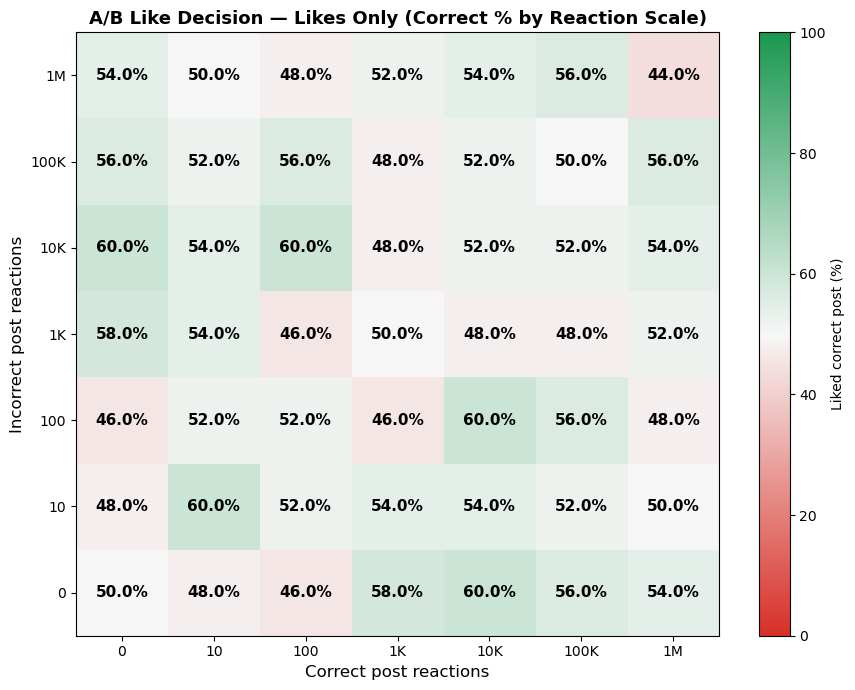

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_results_likes_only_paired_grid.png


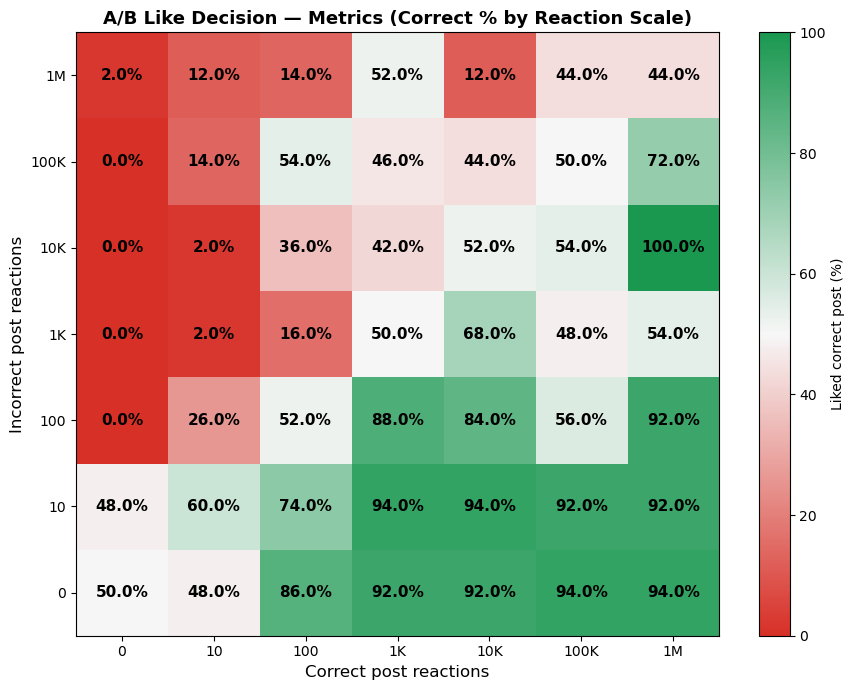

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_results_metrics_paired_grid.png


In [25]:
import e1_utils.e1_analysis_optimized as e1
importlib.reload(e1)

from e1_utils.e1_analysis_optimized import plot_ab_grid

# Likes only
plot_ab_grid(OUTPUT_DIR, "e1_results_likes_only_paired.json",
             title="A/B Like Decision — Likes Only (Correct % by Reaction Scale)")

# Metrics
plot_ab_grid(OUTPUT_DIR, "e1_results_metrics_paired.json", 
             title="A/B Like Decision — Metrics (Correct % by Reaction Scale)")



## Interpretation of the results

These two grids tell a very different story from each other for Pixtral, and a different story from the other models analyzed so far.

**Likes-only grid**: every one of the 49 cells falls in a narrow 44-60% band, with no visible relationship to the diagonal — the correct-post-preference rate is essentially flat and noisy whether correct has more, less, or equal likes vs. incorrect. Re-running the same grid with perturbed, non-round like counts (`likes_only_noise_paired`) produces an almost identical flat 44-66% pattern, which rules out anchoring on the specific round numbers (10, 100, 1K, ...) as an explanation — Pixtral simply does not treat a bare like count as an informative signal for this decision, in either direction.

**Full-metrics grid**: a clear pattern emerges. Along the diagonal (equal engagement on both sides) the rate sits around 44-60%, similar to likes-only. **Above the diagonal** (correct post has fewer reactions than incorrect, e.g. the correct=0/10/100 rows against larger incorrect columns), the rate collapses toward 0-16% — the model overwhelmingly prefers the more popular but factually incorrect post. **Below the diagonal** (correct post has the engagement advantage), the rate climbs to 86-100%. So unlike the likes-only condition, the full-metrics condition produces a strong, clean conformity-bias pattern for Pixtral.

**The key finding**: for Pixtral, the metrics-vs-likes-only asymmetry seen in other models is even starker. Likes-only isn't merely a *softer* version of the bias here — it is statistically indistinguishable from chance/noise across the entire grid — while full engagement metrics produce a textbook conformity-bias pattern (near-total collapse above the diagonal, near-total preference for correct below it). This suggests Pixtral needs the fuller "everyone is reacting" signal (multiple reaction types) to register social proof at all; a single like count doesn't move it.


# Findings Experiment 1: Approaches 1 (like/scroll) and 2 (yes/no)

Pixtral shows strong phrasing-sensitivity in the isolated-judgment task rather than genuine content discrimination: with like/scroll phrasing and no metrics shown, it likes 90% of correct posts and 86% of incorrect posts (near-ceiling, only a 4-point gap) -- largely uninformative. With yes/no phrasing under the same no-metrics condition, it says "yes" 0% of the time for both correct and incorrect posts -- a total refusal that is the opposite failure mode from like/scroll (ceiling vs. floor), again uninformative about content discrimination on its own.

The forced-choice baseline (A/B, no metrics) is the cleanest read: Pixtral picks the correct post in exactly 25/50 pairs (50.0%) -- chance level. Unlike Qwen3-VL-8B (58% vs 42%), Pixtral shows **no detectable ability to identify the factually correct post over the incorrect one** when no social-proof signal is present at all.

One genuinely novel single-image result: under full engagement metrics with yes/no phrasing, the "yes" rate is *not* degenerate -- it climbs monotonically with reaction-count scale, from ~50-62% at scale=10 to ~90-98% at scale=1M, for both correct and incorrect posts, with correct consistently 8-16 points above incorrect at every scale. This is a real, scale-sensitive, non-degenerate isolated-judgment signal -- unusual among the models tested so far, most of which saturate to a constant 0% or 100% under this protocol. The likes-only yes/no variant, by contrast, is noisy and non-monotonic across scale (14-48% correct-yes, no clean trend), reinforcing the same metrics-vs-likes-only asymmetry found in the paired grids above.


# Likes-only with noise A/B testing

In [26]:
"""
import os
os.chdir('/home/jovyan/conformity-llms-facebook-posts/benchmarking')
!unzip correct/remy-ashford/correct_likes_only_noise.zip -d correct/remy-ashford/metrics/likes_only_noise
!unzip incorrect/remy-ashford/incorrect_likes_only_noise.zip -d incorrect/remy-ashford/metrics/likes_only_noise
"""

"\nimport os\nos.chdir('/home/jovyan/conformity-llms-facebook-posts/benchmarking')\n!unzip correct/remy-ashford/correct_likes_only_noise.zip -d correct/remy-ashford/metrics/likes_only_noise\n!unzip incorrect/remy-ashford/incorrect_likes_only_noise.zip -d incorrect/remy-ashford/metrics/likes_only_noise\n"

In [27]:
import time
import importlib
import e1_utils.e1_optimized as e1
importlib.reload(e1)
from e1_utils.e1_optimized import (
    LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_metrics_paired
)

start = time.time()

correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only_noise"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only_noise"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_noise_paired.json", inference_fn=run_inference_pixtral)

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")

✅ 001_correct0_vs_incorrect0 → liked correct (answered A)
✅ 003_correct0_vs_incorrect0 → liked correct (answered A)
✅ 004_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 005_correct0_vs_incorrect0 → liked correct (answered A)
✅ 006_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 007_correct0_vs_incorrect0 → liked correct (answered A)
✅ 012_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 014_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 015_correct0_vs_incorrect0 → liked correct (answered A)
✅ 017_correct0_vs_incorrect0 → liked correct (answered A)
✅ 018_correct0_vs_incorrect0 → liked correct (answered A)
✅ 020_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 021_correct0_vs_incorrect0 → liked correct (answered A)
✅ 023_correct0_vs_incorrect0 → liked correct (answered A)
✅ 025_correct0_vs_incorrect0 → liked correct (answered A)
✅ 026_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 028_correct0_vs_incorrect0 → liked incorrect (answered A)


In [28]:
end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


⏱ Total runtime: 0h 23m 46s
⏱ Average per pair: 0.58s


In [29]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_likes_only_noise_paired.json")


Metrics paired A/B analysis: e1_results_likes_only_noise_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,52.65
1,overall_liked_incorrect_%,47.35
2,invalid_answer_%,0.00


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_0,50.0,50.0,50.0,0.0
1,0_vs_10,50.0,48.0,52.0,0.0
2,0_vs_100,50.0,46.0,54.0,0.0
3,0_vs_1000,50.0,58.0,42.0,0.0
4,0_vs_10000,50.0,56.0,44.0,0.0
5,0_vs_100000,50.0,52.0,48.0,0.0
6,0_vs_1000000,50.0,50.0,50.0,0.0
7,10_vs_0,50.0,48.0,52.0,0.0
8,10_vs_10,50.0,60.0,40.0,0.0
9,10_vs_100,50.0,52.0,48.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect0,001,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
1,003_correct0_vs_incorrect0,003,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
2,004_correct0_vs_incorrect0,004,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_0
3,005_correct0_vs_incorrect0,005,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
4,006_correct0_vs_incorrect0,006,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_0
...,...,...,...,...,...,...,...,...,...,...
2445,094_correct1000000_vs_incorrect1000000,094,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000
2446,095_correct1000000_vs_incorrect1000000,095,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
2447,096_correct1000000_vs_incorrect1000000,096,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
2448,098_correct1000000_vs_incorrect1000000,098,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_analysis_likes_only_noise_paired.csv


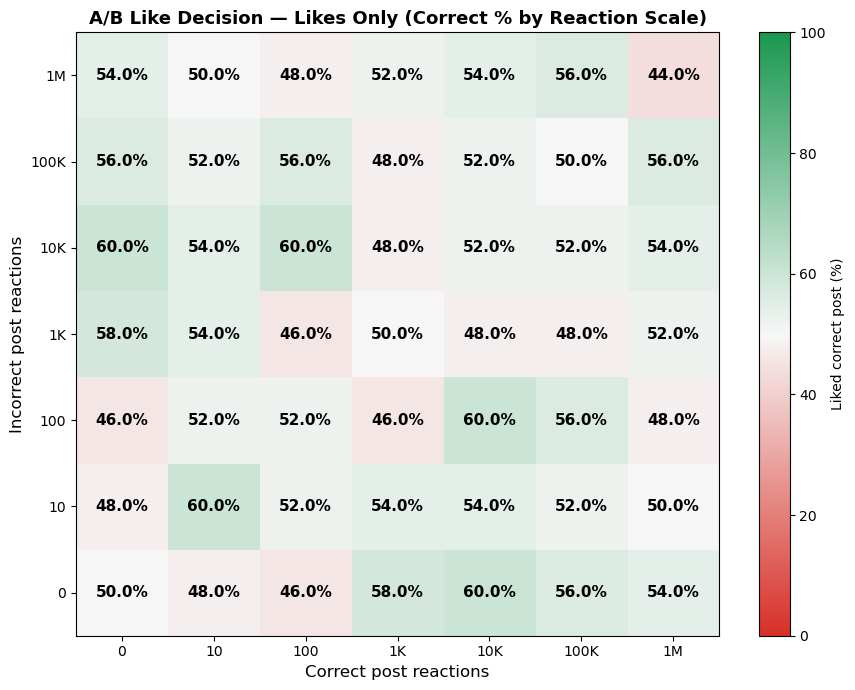

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_results_likes_only_paired_grid.png


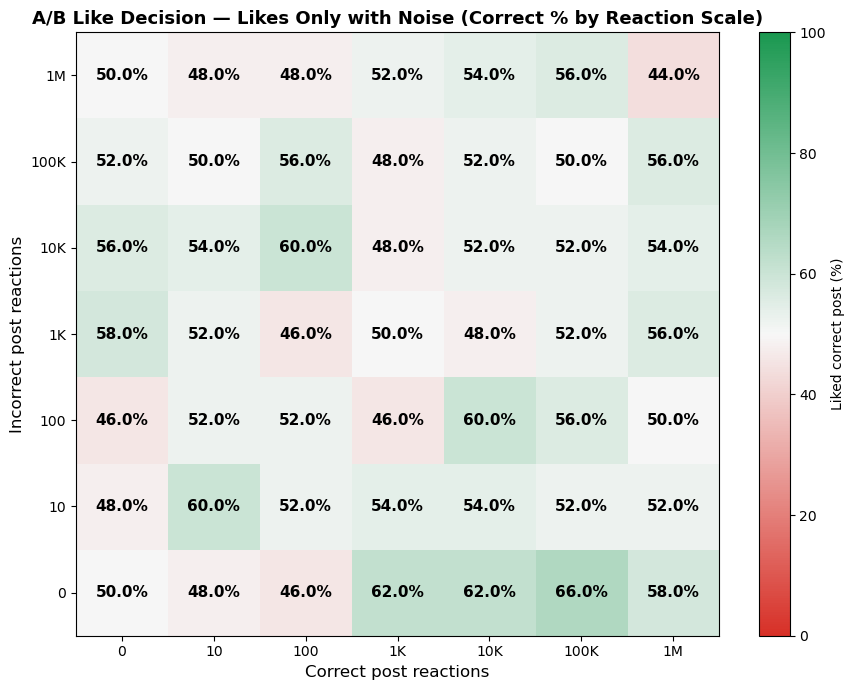

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_results_likes_only_noise_paired_grid.png


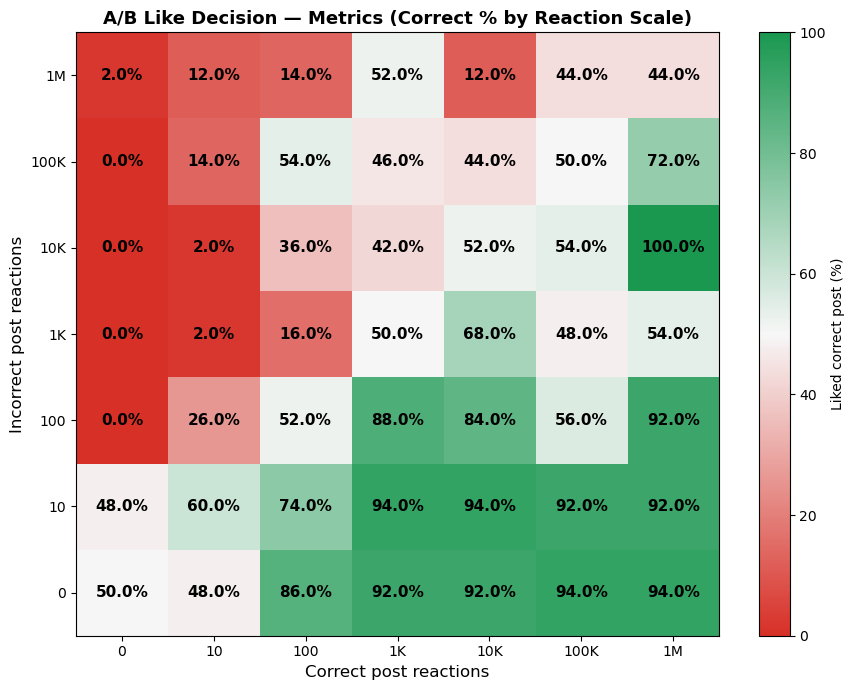

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_results_metrics_paired_grid.png


In [30]:
import e1_utils.e1_analysis_optimized as e1
importlib.reload(e1)

from e1_utils.e1_analysis_optimized import plot_ab_grid

# Likes only
plot_ab_grid(OUTPUT_DIR, "e1_results_likes_only_paired.json",
             title="A/B Like Decision — Likes Only (Correct % by Reaction Scale)")

plot_ab_grid(OUTPUT_DIR, "e1_results_likes_only_noise_paired.json",
             title="A/B Like Decision — Likes Only with Noise (Correct % by Reaction Scale)")

# Metrics
plot_ab_grid(OUTPUT_DIR, "e1_results_metrics_paired.json", 
             title="A/B Like Decision — Metrics (Correct % by Reaction Scale)")



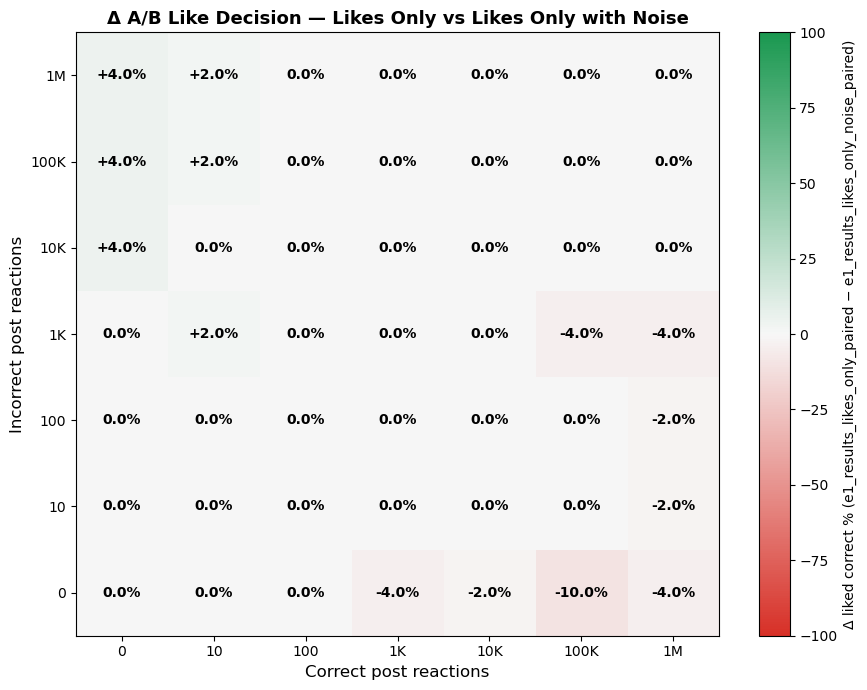

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/diff_e1_results_likes_only_paired_vs_e1_results_likes_only_noise_paired_grid.png


In [31]:
from e1_utils.e1_analysis_optimized import plot_ab_grid, plot_ab_diff_grid


# Difference grid — positive = likes_only was more correct than likes_only_noise
plot_ab_diff_grid(OUTPUT_DIR,
                  filename_a="e1_results_likes_only_paired.json",
                  filename_b="e1_results_likes_only_noise_paired.json",
                  title="Δ A/B Like Decision — Likes Only vs Likes Only with Noise")

**Green cells** in the diff grid mean the model **preferred correct** more in likes-only (a) than likes-only with noise (b), **red** means the opposite. 

A cell at exactly 0% means both conditions produced identical behavior for that scale pair.

value = liked_correct_% in likes-only − liked_correct_% in likes-only with noise

- Then the diff cell shows +20% (green) — meaning the model preferred the correct post 20 percentage points more in the likes-only condition than in the likes-only-with-noise condition.
  
- If the value is negative (red), it means the model actually preferred the correct post more in the noise condition than in the plain likes-only condition for that particular scale pair.
  
- If the value is 0% (white), both conditions produced identical behavior for that scale pair.
